In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler, MinMaxScaler , RobustScaler ,OrdinalEncoder ,OneHotEncoder,LabelEncoder
from sklearn.feature_selection import f_regression

In [2]:
Data = pd.read_csv('adult_with_headers (1).csv')
Data.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
Data.shape

(32561, 15)

In [4]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [5]:
Data.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [6]:
Data.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [7]:
for col in Data.select_dtypes(include=['object']).columns:
    print(col)
    print(Data[col].unique())

workclass
[' State-gov' ' Self-emp-not-inc' ' Private' ' Federal-gov' ' Local-gov'
 ' ?' ' Self-emp-inc' ' Without-pay' ' Never-worked']
education
[' Bachelors' ' HS-grad' ' 11th' ' Masters' ' 9th' ' Some-college'
 ' Assoc-acdm' ' Assoc-voc' ' 7th-8th' ' Doctorate' ' Prof-school'
 ' 5th-6th' ' 10th' ' 1st-4th' ' Preschool' ' 12th']
marital_status
[' Never-married' ' Married-civ-spouse' ' Divorced'
 ' Married-spouse-absent' ' Separated' ' Married-AF-spouse' ' Widowed']
occupation
[' Adm-clerical' ' Exec-managerial' ' Handlers-cleaners' ' Prof-specialty'
 ' Other-service' ' Sales' ' Craft-repair' ' Transport-moving'
 ' Farming-fishing' ' Machine-op-inspct' ' Tech-support' ' ?'
 ' Protective-serv' ' Armed-Forces' ' Priv-house-serv']
relationship
[' Not-in-family' ' Husband' ' Wife' ' Own-child' ' Unmarried'
 ' Other-relative']
race
[' White' ' Black' ' Asian-Pac-Islander' ' Amer-Indian-Eskimo' ' Other']
sex
[' Male' ' Female']
native_country
[' United-States' ' Cuba' ' Jamaica' ' India' '

In [8]:
Data.replace(" ?", pd.NA, inplace=True)
Data.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64

In [9]:
Data.fillna({'workclass':Data.workclass.mode()[0],'occupation':Data.occupation.mode()[0],'native_country':Data.native_country.mode()[0]},inplace=True)

In [10]:
Data.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [11]:
num_cols = [col for col in Data.columns if Data[col].dtype != 'object']
cat_cols = [col for col in Data.columns if Data[col].dtype == 'object']
print(num_cols)
print(cat_cols)

['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country', 'income']


In [12]:
Data.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [13]:
num_cols = [i for i in Data.columns if Data[i].dtype != 'object']
cat_cols = [i for i in Data.columns if Data[i].dtype == 'object']
print(num_cols)
print(cat_cols)

['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country', 'income']


In [14]:
target = Data[['income']]
features = Data.drop(columns=['income'])
features.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba


In [15]:
target.head()

,income
0,<=50K
1,<=50K
2,<=50K
3,<=50K
4,<=50K


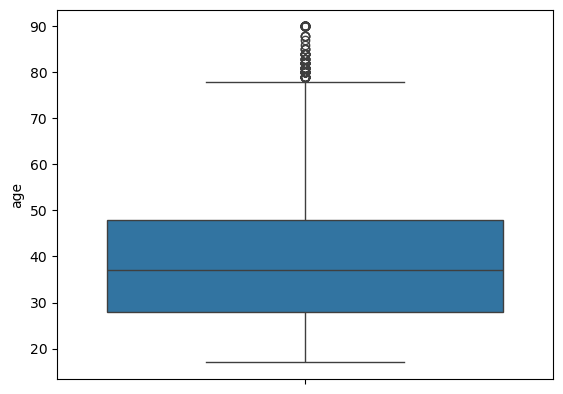

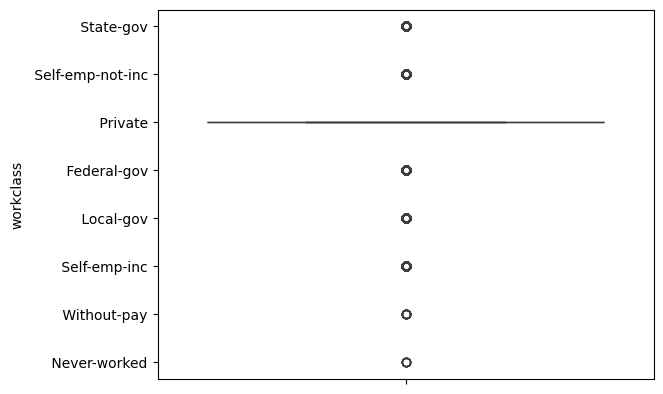

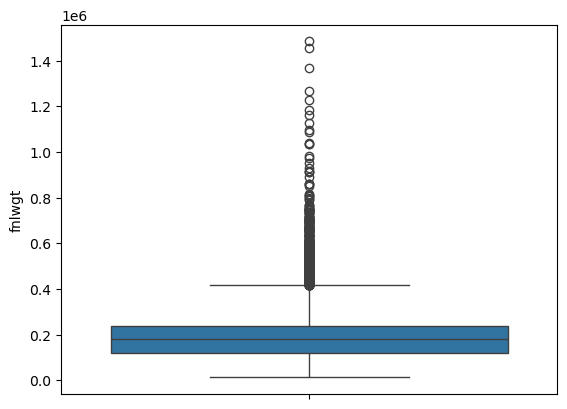

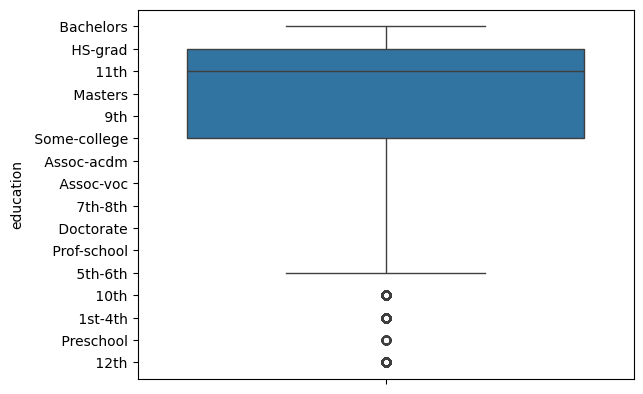

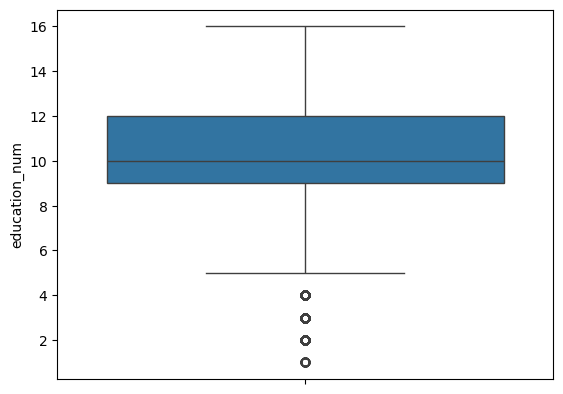

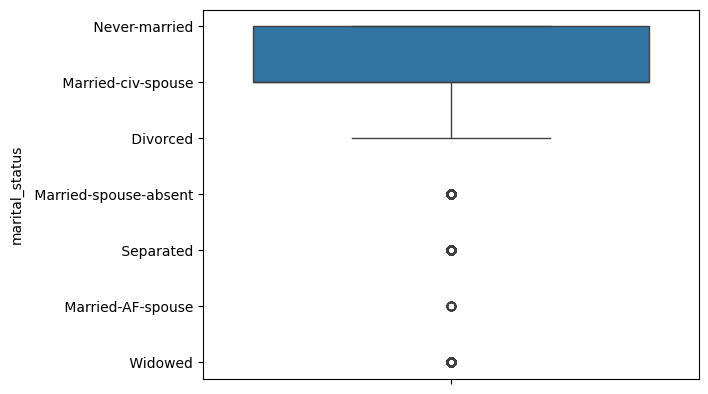

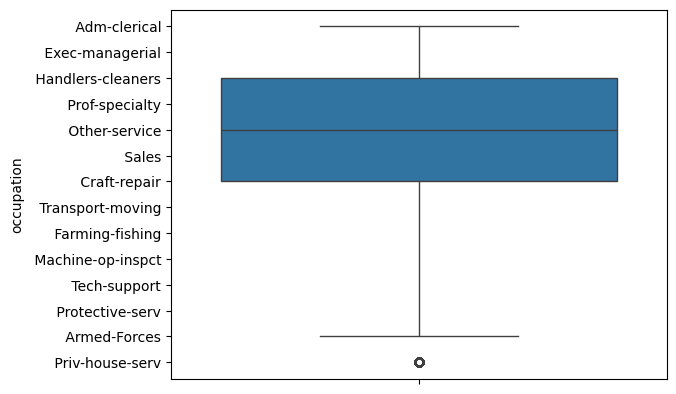

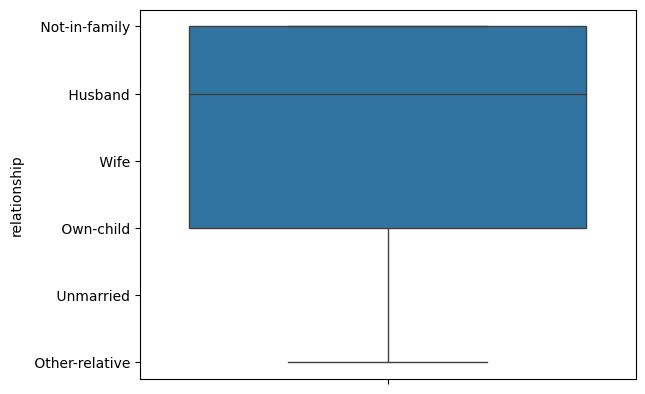

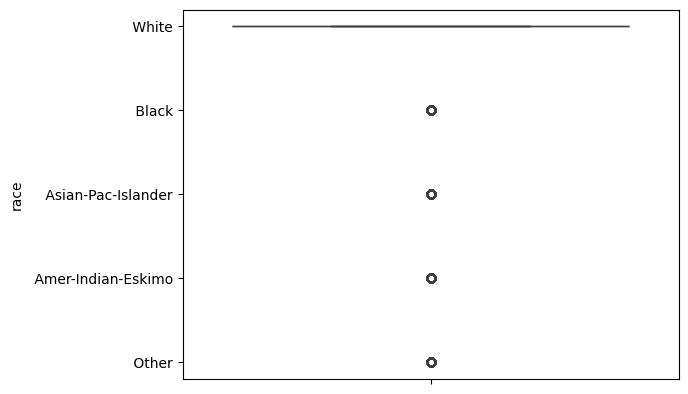

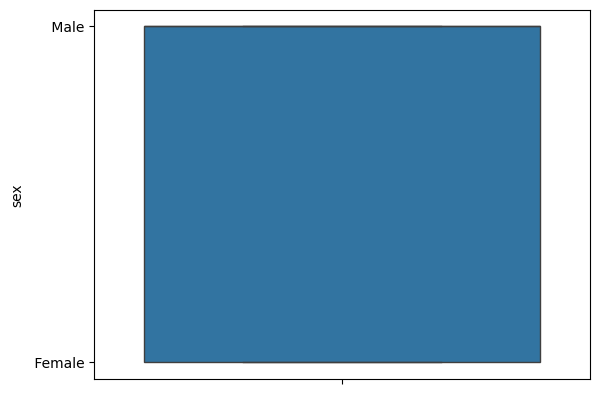

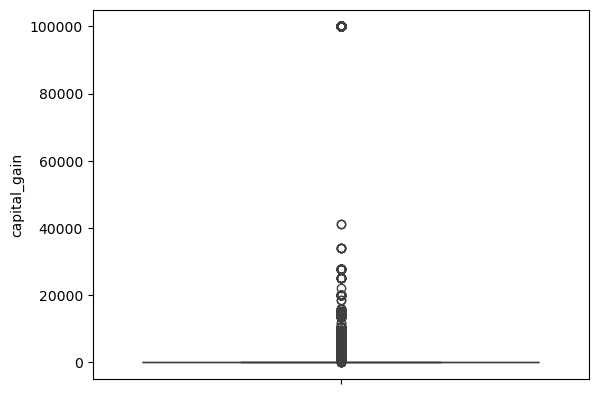

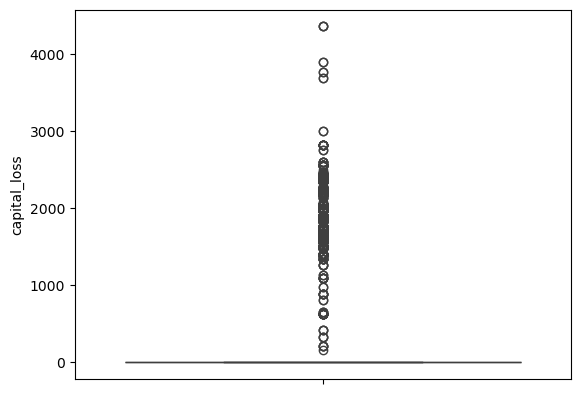

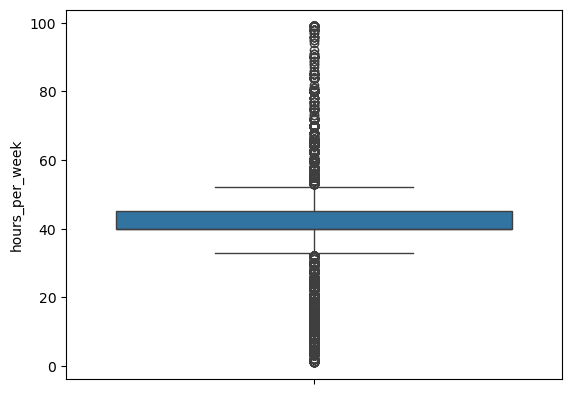

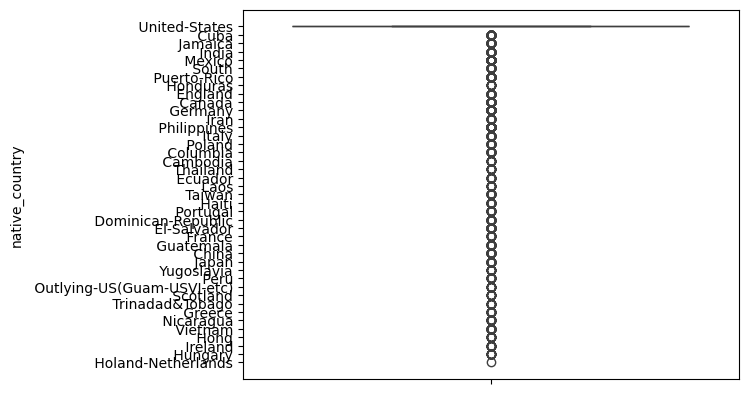

In [16]:
for col in features.columns:
    sns.boxplot(data=features,y=col)
    plt.show()

In [17]:
### outlier capping
def outlier_capping(df,columns):
    Q1= df[columns].quantile(0.25)
    Q3= df[columns].quantile(0.75)
    IQR= Q3-Q1
    lower_extreme= Q1-1.5*IQR
    upper_extreme= Q3+1.5*IQR
    df[columns]= df[columns].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x)
for col in features.select_dtypes(include=['int','float']).columns:
    outlier_capping(features,col)

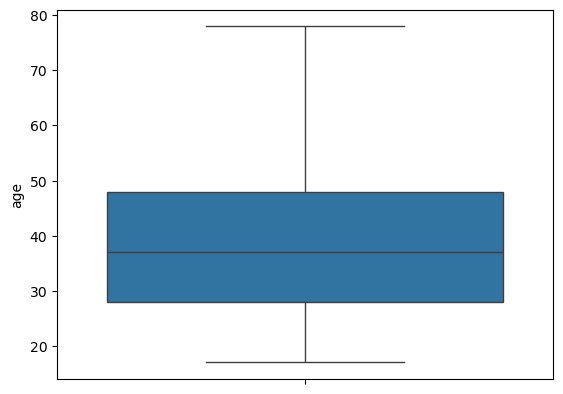

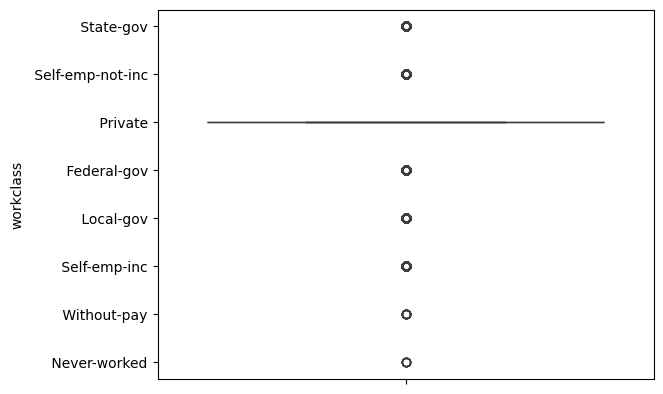

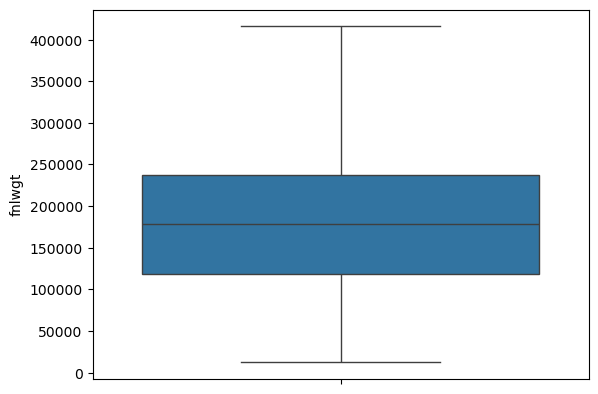

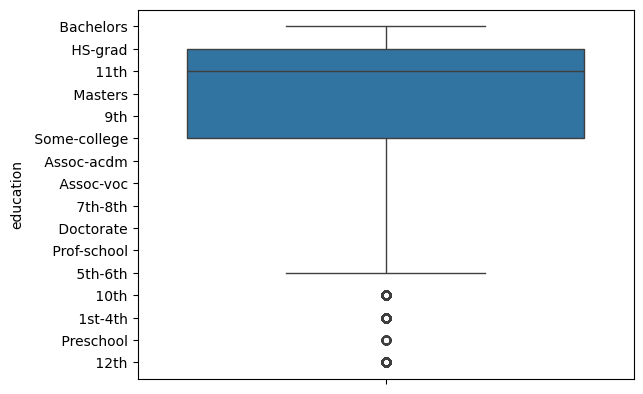

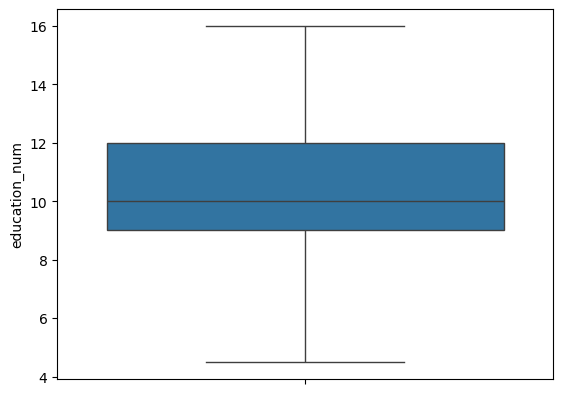

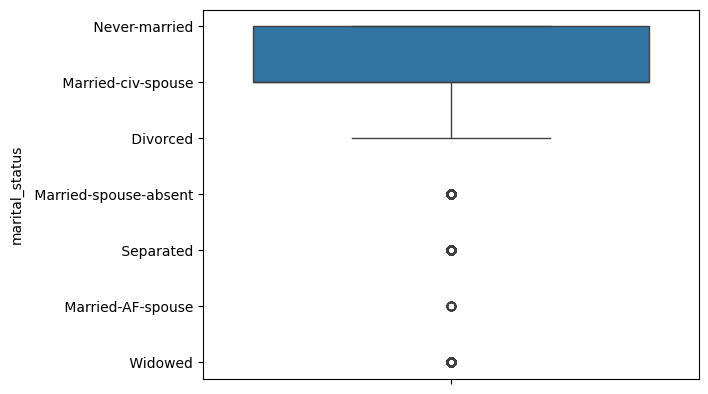

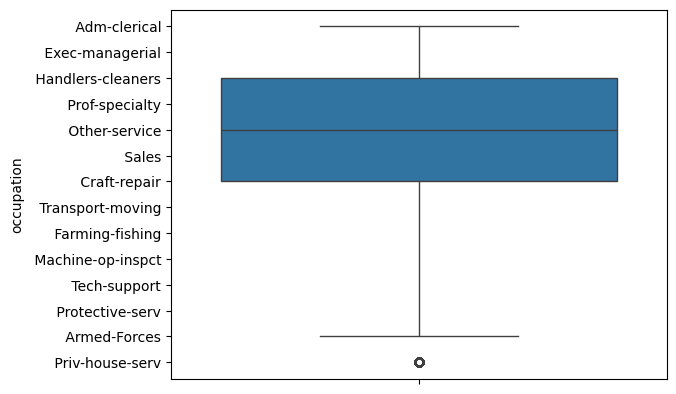

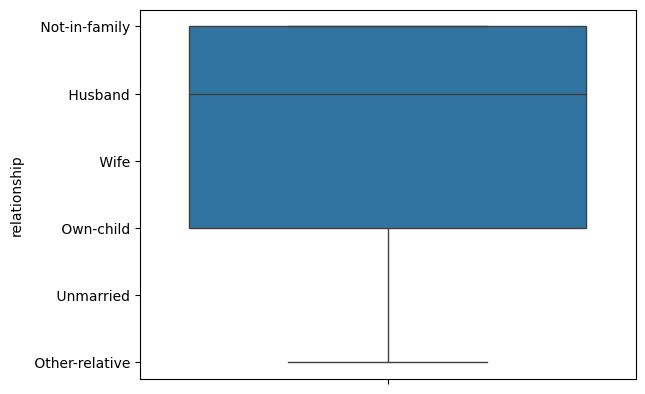

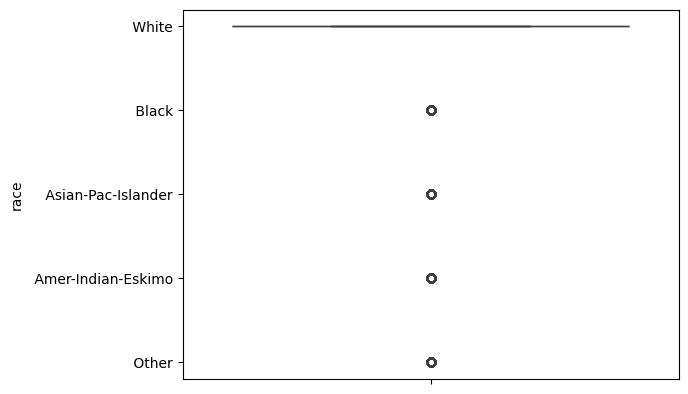

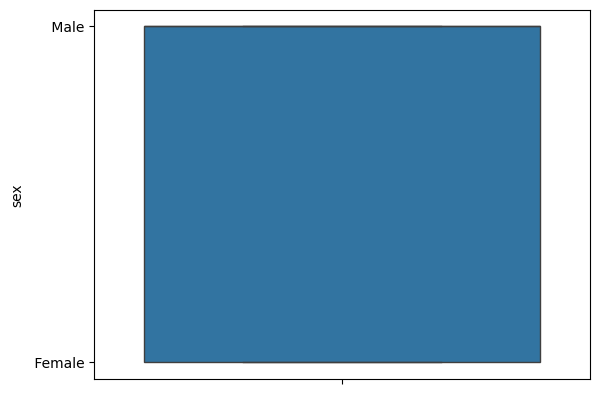

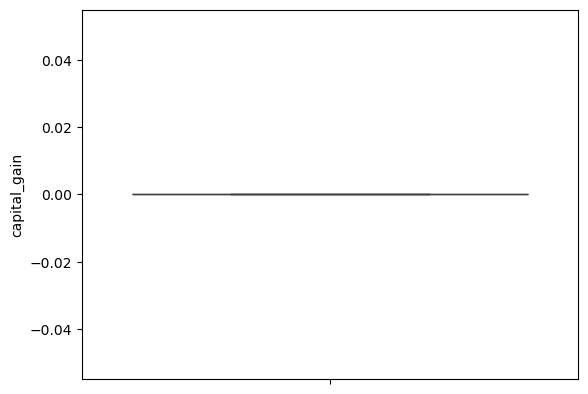

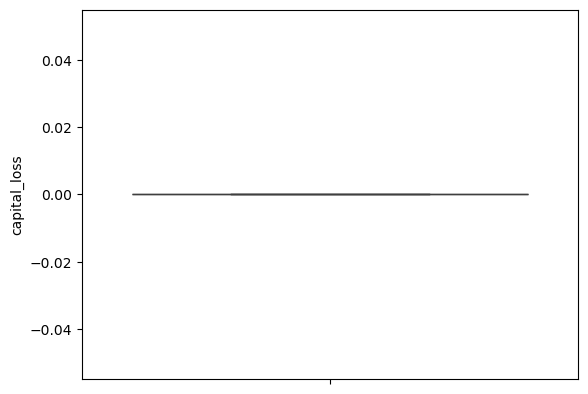

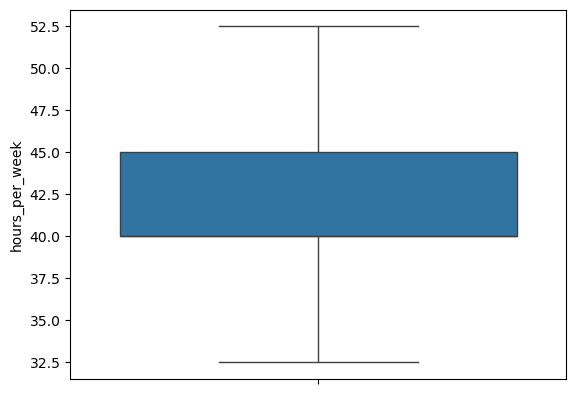

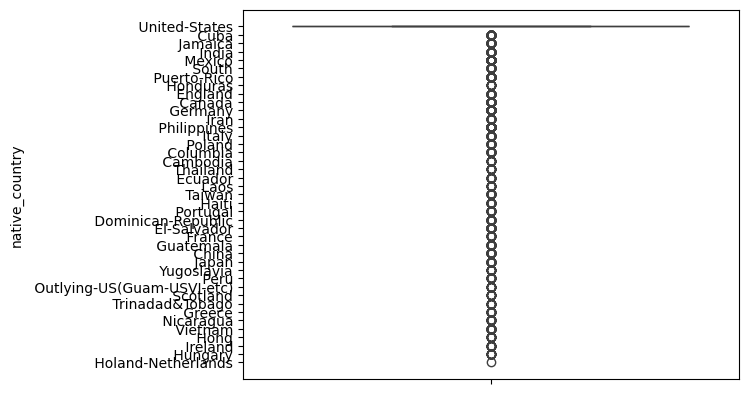

In [18]:
for col in features.columns:
    sns.boxplot(data=features,y=col)
    plt.show()

In [19]:
features.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country
0,39.0,State-gov,77516.0,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,0.0,0.0,40.0,United-States
1,50.0,Self-emp-not-inc,83311.0,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,32.5,United-States
2,38.0,Private,215646.0,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States
3,53.0,Private,234721.0,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States
4,28.0,Private,338409.0,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba


In [20]:
## Apply StandardScaler
std_scale = StandardScaler()
x_std = features.copy()
x_std[num_cols] = std_scale.fit_transform(x_std[num_cols])

In [21]:
x_std.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country
0,0.032782,State-gov,-1.149114,Bachelors,1.169103,Never-married,Adm-clerical,Not-in-family,White,Male,0.0,0.0,-0.194354,United-States
1,0.844236,Self-emp-not-inc,-1.088196,Bachelors,1.169103,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,-1.406591,United-States
2,-0.040986,Private,0.302927,HS-grad,-0.457091,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,-0.194354,United-States
3,1.065541,Private,0.503446,11th,-1.270187,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,-0.194354,United-States
4,-0.778671,Private,1.593428,Bachelors,1.169103,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,-0.194354,Cuba


In [22]:
## Apply MinMax Scaller
mm_scaler = MinMaxScaler()
x_mm = features.copy()
x_mm[num_cols] = mm_scaler.fit_transform(x_mm[num_cols])

In [23]:
x_mm.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country
0,0.360656,State-gov,0.161622,Bachelors,0.739130,Never-married,Adm-clerical,Not-in-family,White,Male,0.0,0.0,0.375,United-States
1,0.540984,Self-emp-not-inc,0.175980,Bachelors,0.739130,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,0.000,United-States
2,0.344262,Private,0.503865,HS-grad,0.391304,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,0.375,United-States
3,0.590164,Private,0.551127,11th,0.217391,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,0.375,United-States
4,0.180328,Private,0.808034,Bachelors,0.739130,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,0.375,Cuba


In [24]:
## In this assignment, both Standard Scaling and Min-Max Scaling were applied separately to the numerical features. 
## StandardScaler was used to normalize features with zero mean and unit variance, making it suitable for models sensitive 
## to feature distribution such as SVM and Logistic Regression. 
## Min-Max Scaling was applied to transform features into a fixed range of 0 to 1, which is beneficial for distance-based and neural network models. 
## Both techniques were demonstrated for comparison purposes, but only one scaler is used at a time depending on the algorithm.

In [25]:
cat_cols

['workclass',
 'education',
 'marital_status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native_country',
 'income']

In [26]:
Data[cat_cols].nunique()

workclass          8
education         16
marital_status     7
occupation        14
relationship       6
race               5
sex                2
native_country    41
income             2
dtype: int64

In [27]:
cat_cols = features.select_dtypes(include=['object', 'category']).columns
cols = [col for col in cat_cols if features[col].nunique() < 5]
cols

['sex']

In [28]:
### one hot encoder
one_hot=OneHotEncoder()
encoded_df=pd.DataFrame(one_hot.fit_transform(features[cols]).toarray(),columns=one_hot.get_feature_names_out(cols))
encoded_df

,sex_ Female,sex_ Male
0,0.0,1.0
1,0.0,1.0
2,0.0,1.0
3,0.0,1.0
4,1.0,0.0
...,...,...
32556,1.0,0.0
32557,0.0,1.0
32558,1.0,0.0
32559,0.0,1.0


In [29]:
x_mm.drop(columns='sex',inplace=True)
x_mm = pd.concat([x_mm, encoded_df], axis=1)
x_mm.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,sex_ Female,sex_ Male
0,0.360656,State-gov,0.161622,Bachelors,0.739130,Never-married,Adm-clerical,Not-in-family,White,0.0,0.0,0.375,United-States,0.0,1.0
1,0.540984,Self-emp-not-inc,0.175980,Bachelors,0.739130,Married-civ-spouse,Exec-managerial,Husband,White,0.0,0.0,0.000,United-States,0.0,1.0
2,0.344262,Private,0.503865,HS-grad,0.391304,Divorced,Handlers-cleaners,Not-in-family,White,0.0,0.0,0.375,United-States,0.0,1.0
3,0.590164,Private,0.551127,11th,0.217391,Married-civ-spouse,Handlers-cleaners,Husband,Black,0.0,0.0,0.375,United-States,0.0,1.0
4,0.180328,Private,0.808034,Bachelors,0.739130,Married-civ-spouse,Prof-specialty,Wife,Black,0.0,0.0,0.375,Cuba,1.0,0.0


In [30]:
cols = [col for col in cat_cols if features[col].nunique() >= 5]
cols

['workclass',
 'education',
 'marital_status',
 'occupation',
 'relationship',
 'race',
 'native_country']

In [31]:
lab_enc = LabelEncoder()

In [32]:
for col in cols:
    x_mm[col] = lab_enc.fit_transform(x_mm[col])

In [33]:
x_mm.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,sex_ Female,sex_ Male
0,0.360656,6,0.161622,9,0.739130,4,0,1,4,0.0,0.0,0.375,38,0.0,1.0
1,0.540984,5,0.175980,9,0.739130,2,3,0,4,0.0,0.0,0.000,38,0.0,1.0
2,0.344262,3,0.503865,11,0.391304,0,5,1,4,0.0,0.0,0.375,38,0.0,1.0
3,0.590164,3,0.551127,1,0.217391,2,5,0,2,0.0,0.0,0.375,38,0.0,1.0
4,0.180328,3,0.808034,9,0.739130,2,9,5,2,0.0,0.0,0.375,4,1.0,0.0


In [37]:
## To Create at least 2 new features that could be beneficial for the model

In [45]:
# 1 High net capital → higher probability of high income.
Data['total_capital'] = Data['capital_gain'] - Data['capital_loss']

In [46]:
# 2 Education Level Strength
Data['education_strength'] = Data['education_num'] * Data['age']

In [48]:
#capital_gain is extremely skewed most values = 0 ,few values = very large
# +1 is used to avoid log(0)
Data['capital_gain_log'] = np.log1p(Data['capital_gain'])

In [49]:
# log(1+x) We add 1 to avoid log(0) error.
Data['capital_gain_log'] = np.log1p(Data['capital_gain'])